In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from qsmp import tree
from spectrum import MultiTapering

In [23]:
plt.rcParams.update({
    "text.usetex": True,    
    "font.size": 12,
    "font.family": "serif",
})
img_dir = Path('../results/img/')

In [3]:
data_file = Path('../data/study019-preictal/qsmp_T_splice.npz')
with np.load(data_file, allow_pickle=True) as data:
    T = data['T']

In [4]:
QSMP_file = Path('../results/study019-interictal/qsmp_m-512_sigma-0.9_1.0_2.0_4.0_6.0_8.0_12.0_16.0_rect-50_minfilt-256.npz')
with np.load(QSMP_file) as data:
    density = data['density'].T
    NNdist = data['profile'].T
    NNindex = data['indices'].T

In [6]:
def find_tau(k, subseq_len, density, NNindex, NNdist):    
    max_tau = np.max(NNdist)
    min_tau = np.min(NNdist[NNdist>0])    
    step = (max_tau - min_tau)/2
    tau = min_tau + step
    prev_left = min_tau
    prev_right = max_tau
    while True:        
        NNd, NNi, modes, cluster_size = tree.tree2clusters(
            subseq_len, density, NNindex, NNdist, tau)
        n_modes = modes.size        
        if n_modes == k:
            break
        elif n_modes > k:
            step = (prev_right - tau)/2
            prev_left = tau
            tau = tau + step            
        else:
            step = (tau - prev_left)/2
            prev_right = tau
            tau = tau - step
    return tau

In [17]:
subseq_len, k = 512, 128
i_sigma = 1
tau = find_tau(k, subseq_len, density[i_sigma], NNindex[i_sigma], NNdist[i_sigma])
print(tau)

6.157387312046579


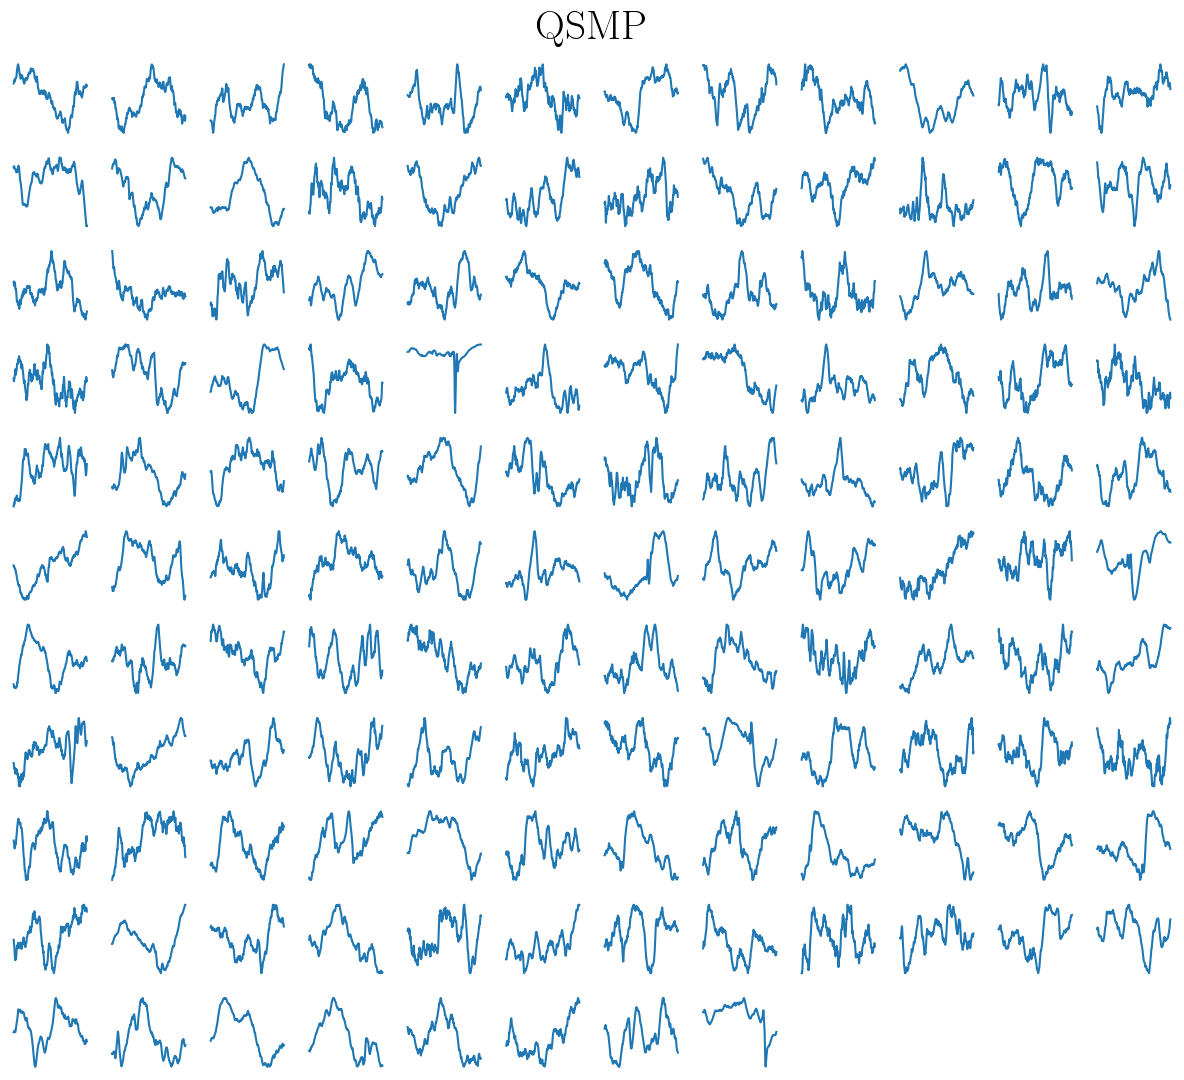

In [27]:
# tau = 7.25367
NNd, NNi, modes_idx, cluster_size = tree.tree2clusters(
    subseq_len, density[i_sigma], NNindex[i_sigma],
    NNdist[i_sigma], tau
)
n_rows = int(np.sqrt(k))
n_cols = np.ceil(k/n_rows).astype(int)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols, n_rows))
ax = ax.flatten()
for i in range(len(ax)):
    if i < k:
        wave = T[modes_idx[i]:modes_idx[i]+subseq_len]
        ax[i].plot(wave)
    ax[i].axis('off')
fig.suptitle('QSMP', fontsize=30)
plt.tight_layout()
fpath = img_dir.joinpath('study019-interictal_waves_QSMP.pdf')
plt.savefig(fpath, bbox_inches='tight', pad_inches=0)

In [19]:
sikmeans_file = Path('../results/study019-interictal/sikmeans_k-128_P-512_wlen-768.npz')
with np.load(sikmeans_file) as data:
    centroids = data['centroids']
    labels = data['labels']
    shifts = data['shifts']
    distances = data['distances']

ul, label_count = np.unique(labels, return_counts=True)
isort = np.argsort(-label_count)
centroids = centroids[isort]
label_count = label_count[isort]

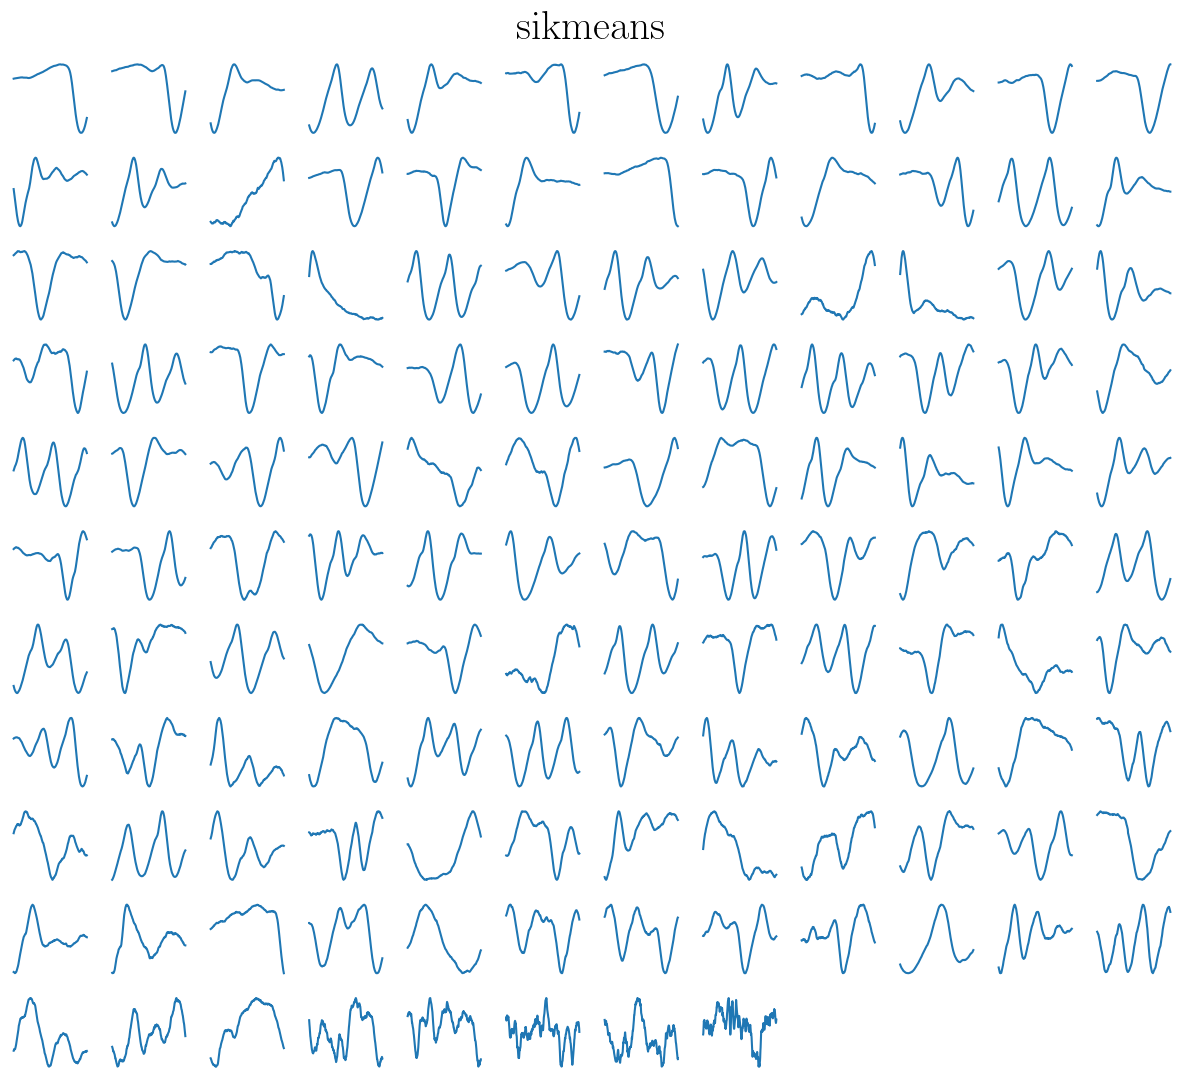

In [28]:
fig, ax = plt.subplots(11, 12, figsize=(12,11))
ax = ax.flatten()
for i in range(len(ax)):
    if i < k:        
        ax[i].plot(centroids[i])
    ax[i].axis('off')

fig.suptitle('sikmeans', fontsize=30)
plt.tight_layout()
fpath = img_dir.joinpath('study019-interictal_waves_sikmeans.pdf')
plt.savefig(fpath, bbox_inches='tight', pad_inches=0)

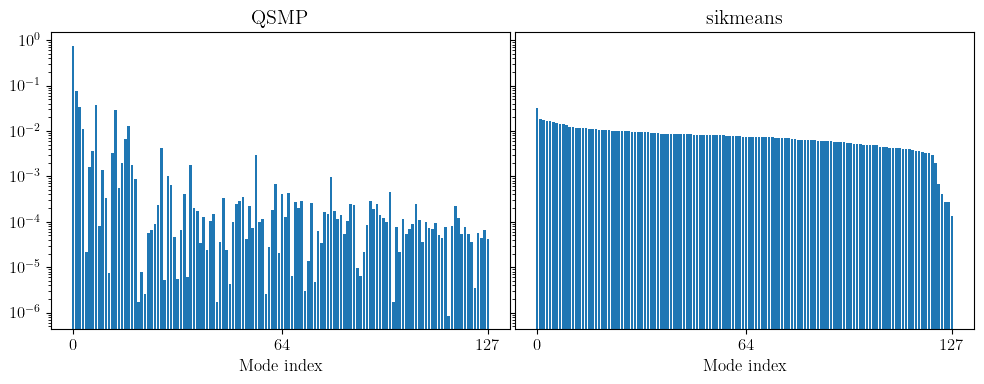

In [26]:
row = (cluster_size, label_count)
titles = ['QSMP', 'sikmeans']

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for i, col in enumerate(row):
    ax[i].bar(np.arange(k), col/col.sum())
    ax[i].set_xticks([0, 64, 127])
    ax[i].set_yscale('log')
    ax[i].set_title(titles[i])
    ax[i].set_xlabel('Mode index')
plt.tight_layout(w_pad=0)
fpath = img_dir.joinpath('study019-interictal_hist_QSMP_vs_sikmeans.pdf')
plt.savefig(fpath, bbox_inches='tight', pad_inches=0)